In [1]:
from scipy.integrate import solve_ivp
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt

In [142]:
A = np.array([
    [0.01, -0.05],
    [-0.01, -0.002],
])

In [143]:
def f(t, Y):
    return (A @ Y.reshape(-1, 2)).flatten()#  + (t - 100) / 200

In [173]:
def get_avg_step_size(Y_0):
    result = solve_ivp(
        f,
        [0, 50],
        Y_0,
    )
    print(result.t[1] - result.t[0])
    print(len(result.t))

    circle_theta = np.linspace(0, 2*np.pi, 100)
    circle_x = np.cos(circle_theta)
    circle_y = np.sin(circle_theta)
    plt.plot(circle_x, circle_y, 'b--', alpha=0.4, linewidth=2, label='Unit circle')
    plt.plot(result.y[1, :], result.y[2, :])

    return len(result.t)

In [174]:
ATA

array([[ 0.0002  , -0.00048 ],
       [-0.00048 ,  0.002504]])

0.0724779519603039
6
0.0277073019557133
6
0.20235610599556406
5
0.16241744705641664
5


(6, 6, 5, 5)

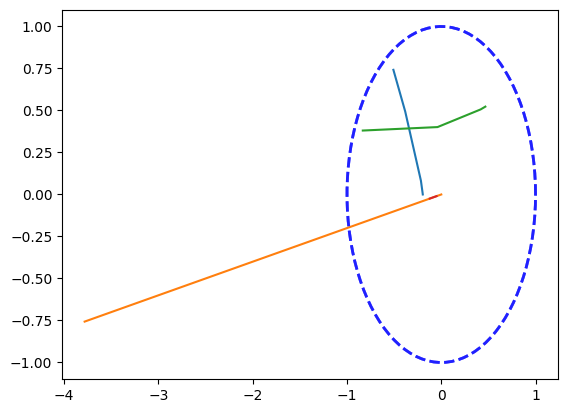

In [175]:
ATA = A.T @ A
EV = linalg.eigh(ATA)[1][0]
Y_opt = np.pad(EV, (0, 2), 'constant')
(
    get_avg_step_size(
        Y_opt
    ),
    get_avg_step_size(
        np.identity(2).flatten()
    ),
    get_avg_step_size(
        np.random.uniform(0, 1, size=(2, 2)).flatten()
    ),
    get_avg_step_size(
        A.flatten()
    )
)

In [176]:
Y_opt = linalg.eigh(A.T @ A)[1][1]
np.linalg.norm((A @ Y_opt))

np.float64(0.050990195135927854)

In [177]:
np.linalg.norm((A @ np.array([1, 0])))

np.float64(0.01414213562373095)

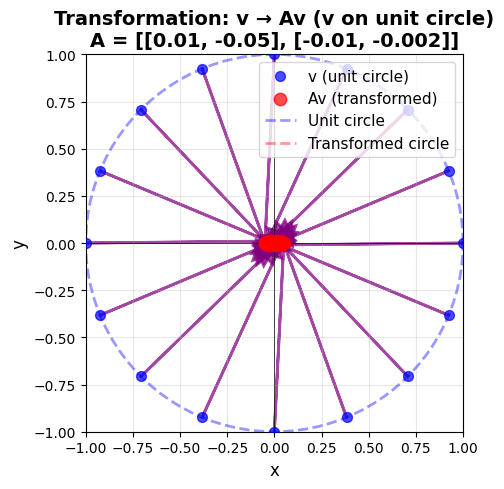

In [178]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix_transformation_circle(A, n_arrows=16):
    """
    Plot arrows from v to Av for vectors v on the unit circle.
    
    Parameters:
    -----------
    A : numpy.ndarray
        2x2 matrix
    n_arrows : int
        Number of arrows to plot around the unit circle
    """
    A = np.array(A)
    
    # Create vectors on the unit circle
    theta = np.linspace(0, 2*np.pi, n_arrows, endpoint=False)
    vectors_v = np.column_stack([np.cos(theta), np.sin(theta)])
    
    # Compute Av for each v
    vectors_Av = (A @ vectors_v.T).T
    
    # Compute displacement: Av - v
    displacement = vectors_Av - vectors_v
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    # Plot arrows from v to Av
    for i in range(len(vectors_v)):
        v = vectors_v[i]
        d = displacement[i]
        ax.arrow(v[0], v[1], d[0], d[1], 
                 head_width=0.12, head_length=0.12,
                 fc='purple', ec='purple', alpha=0.7, linewidth=2)
    
    # Plot original points on unit circle
    ax.scatter(vectors_v[:, 0], vectors_v[:, 1], 
               c='blue', s=50, alpha=0.7, label='v (unit circle)', zorder=5)
    
    # Plot transformed points
    ax.scatter(vectors_Av[:, 0], vectors_Av[:, 1], 
               c='red', s=80, alpha=0.7, label='Av (transformed)', zorder=5)
    
    # Plot unit circle
    circle_theta = np.linspace(0, 2*np.pi, 100)
    circle_x = np.cos(circle_theta)
    circle_y = np.sin(circle_theta)
    ax.plot(circle_x, circle_y, 'b--', alpha=0.4, linewidth=2, label='Unit circle')
    
    # Plot transformed circle (ellipse)
    circle_points = np.column_stack([circle_x, circle_y])
    transformed_circle = (A @ circle_points.T).T
    ax.plot(transformed_circle[:, 0], transformed_circle[:, 1], 
            'r--', alpha=0.4, linewidth=2, label='Transformed circle')
    
    # Formatting
    max_coord = max(1, np.max(np.abs(vectors_Av)) * 1.5)
    ax.set_xlim(-max_coord, max_coord)
    ax.set_ylim(-max_coord, max_coord)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_title(f'Transformation: v → Av (v on unit circle)\nA = [[{A[0,0]}, {A[0,1]}], [{A[1,0]}, {A[1,1]}]]', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='upper right')
    


    plt.tight_layout()
    plt.show()
    

# Example usage
plot_matrix_transformation_circle(A)

# Uncomment to try other examples:
# A2 = np.array([[3, 0], [0, 0.5]])  # Scaling (stretches and compresses)
# plot_matrix_transformation_circle(A2)

# A3 = np.array([[np.cos(np.pi/6), -np.sin(np.pi/6)], 
#                [np.sin(np.pi/6), np.cos(np.pi/6)]])  # Rotation 30 degrees
# plot_matrix_transformation_circle(A3)

# A4 = np.array([[1, 1], [0, 1]])  # Shear
# plot_matrix_transformation_circle(A4)

0.0724779519603039
6
0.0277073019557133
6
0.12269409289214527
6
0.16241744705641664
5


(6, 6, 6, 5)

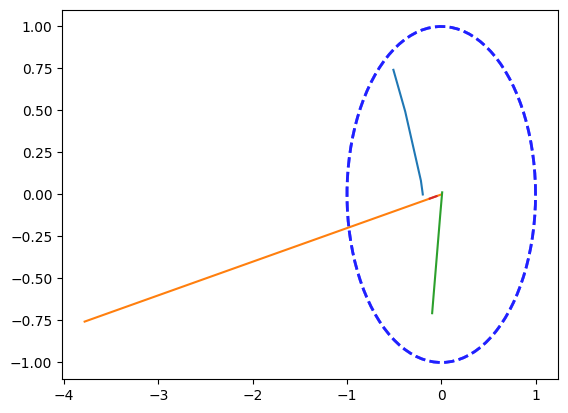

In [180]:
ATA = A.T @ A
EV = linalg.eigh(ATA)[1][0]
Y_opt = np.pad(EV, (0, 2), 'constant')
(
    get_avg_step_size(
        Y_opt
    ),
    get_avg_step_size(
        np.identity(2).flatten()
    ),
    get_avg_step_size(
        np.random.uniform(0, 1, size=(2, 2)).flatten()
    ),
    get_avg_step_size(
        A.flatten()
    )
)

In [181]:
ATA = A.T @ A
EV = linalg.eigh(ATA)[1][0]

In [183]:
EV

array([-0.98058068, -0.19611614])

In [186]:
U, s, Vh = linalg.svd(ATA)
Vh

array([[-0.19611614,  0.98058068],
       [ 0.98058068,  0.19611614]])

In [187]:
A @ Y_opt

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 2)

In [188]:
Y_opt

array([-0.98058068, -0.19611614,  0.        ,  0.        ])